# Support Vector Machines

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets
from sklearn.model_selection import train_test_split

from sklearn import svm
from sklearn.metrics import accuracy_score


In [3]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=5356)

## Linear SVM

In [13]:
clf_linear = svm.SVC(kernel='linear')

clf_linear.fit(X_train, y_train)

SVC(kernel='linear')

In [14]:
y_pred = clf_linear.predict(X_test)

In [15]:
print(accuracy_score(y_test, y_pred))

1.0


In [19]:
## Hyperplane Coefficients

print(clf_linear.coef_)

[[-4.25396508e-04  5.94840650e-01 -9.66102035e-01 -4.46449535e-01]
 [-7.09646077e-03  1.78891446e-01 -5.38425825e-01 -2.92253780e-01]
 [ 7.51236171e-01  5.77397875e-01 -2.13054540e+00 -1.89158680e+00]]


## Non-Linear SVM

In [16]:
rbf = svm.SVC(kernel='rbf')# Radial Basis Function

rbf.fit(X_train, y_train)

y_pred = rbf.predict(X_test)

print(accuracy_score(y_test, y_pred))

1.0


In [20]:
print(rbf.dual_coef_)

[[ 0.24061315  1.          1.          1.          0.12176048  1.
  -0.         -1.         -0.         -1.         -0.         -1.
  -0.         -0.         -0.         -1.         -0.         -0.
  -0.         -0.         -0.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.36237363 -0.         -0.
  -0.         -0.         -0.         -0.         -0.         -0.
  -0.         -0.25625825 -0.         -0.         -0.         -0.
  -0.         -0.         -1.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.         -0.77201233 -0.
  -0.         -0.        ]
 [ 0.          0.70622799  0.99144084  0.          0.          0.33060175
   1.          0.          1.          0.          1.          0.
   1.          1.          1.          0.          1.          1.
   1.          1.          1.          0.89045288  1.          1.
   1.          1.          1.          0.          1.          1.
   1.          1.          1.         -1.

## Polynomial Kernel

In [17]:
poly_svm = svm.SVC(kernel='poly', degree=3)

poly_svm.fit(X_train, y_train)

y_pred = poly_svm.predict(X_test)

print(accuracy_score(y_test, y_pred))

1.0


In [21]:
print(poly_svm.dual_coef_)

[[ 0.53887377  0.          0.01384095 -0.         -0.         -0.55271472
  -0.         -0.         -0.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.10712928 -0.         -0.
  -0.        ]
 [ 0.02918885  0.04024269  0.03769774  1.          1.          0.
   1.          1.          0.65170682  1.          1.         -1.
  -1.         -1.         -0.03707871 -0.61462812 -1.         -1.
  -1.        ]]


## What is a Kernel

- A kernel is a function that computes the dot product between two vectors in some (possibly infinite-dimensional) feature space.
- The kernel trick is a method of using a linear classifier to solve a non-linear problem by mapping the original non-linear observations into a higher-dimensional space.

In [23]:
#Print which kernel function is used
print(clf_linear.kernel)
print(rbf.kernel)
print(poly_svm.kernel)

linear
rbf
poly


### Sigmoid Kernel

In [26]:
sigm_svc = svm.SVC(kernel='sigmoid')

sigm_svc.fit(X_train, y_train)

y_pred = sigm_svc.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.13333333333333333


### Why sigmoid kernel is not used in practice

- The sigmoid kernel is not used in practice because it is not positive definite, which is a requirement for the kernel function.

### Radial Basis Function (RBF) Kernel

- The Radial Basis Function (RBF) kernel is a popular kernel function commonly used in support vector machine classification.
- The RBF kernel is defined as:

$$K(x, x') = \exp\left(-\frac{\|x - x'\|^2}{2\sigma^2}\right)$$

### Visualise the plots

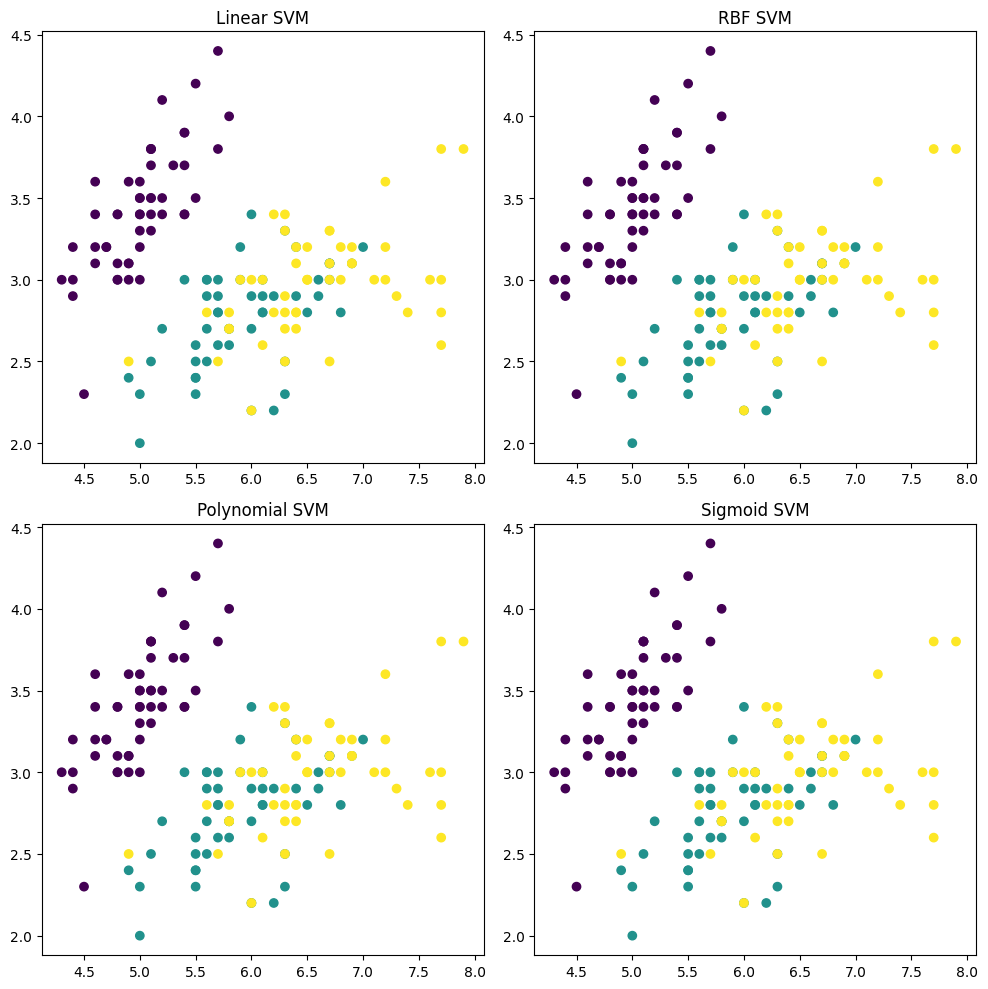

In [27]:
import matplotlib.pyplot as plt

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Plot Linear SVM
axs[0, 0].scatter(X[:, 0], X[:, 1], c=y)
axs[0, 0].set_title('Linear SVM')

# Plot RBF SVM
axs[0, 1].scatter(X[:, 0], X[:, 1], c=y)
axs[0, 1].set_title('RBF SVM')

# Plot Polynomial SVM
axs[1, 0].scatter(X[:, 0], X[:, 1], c=y)
axs[1, 0].set_title('Polynomial SVM')

# Plot Sigmoid SVM
axs[1, 1].scatter(X[:, 0], X[:, 1], c=y)
axs[1, 1].set_title('Sigmoid SVM')

# Adjust spacing between subplots
plt.tight_layout()

# Show the plots
plt.show()


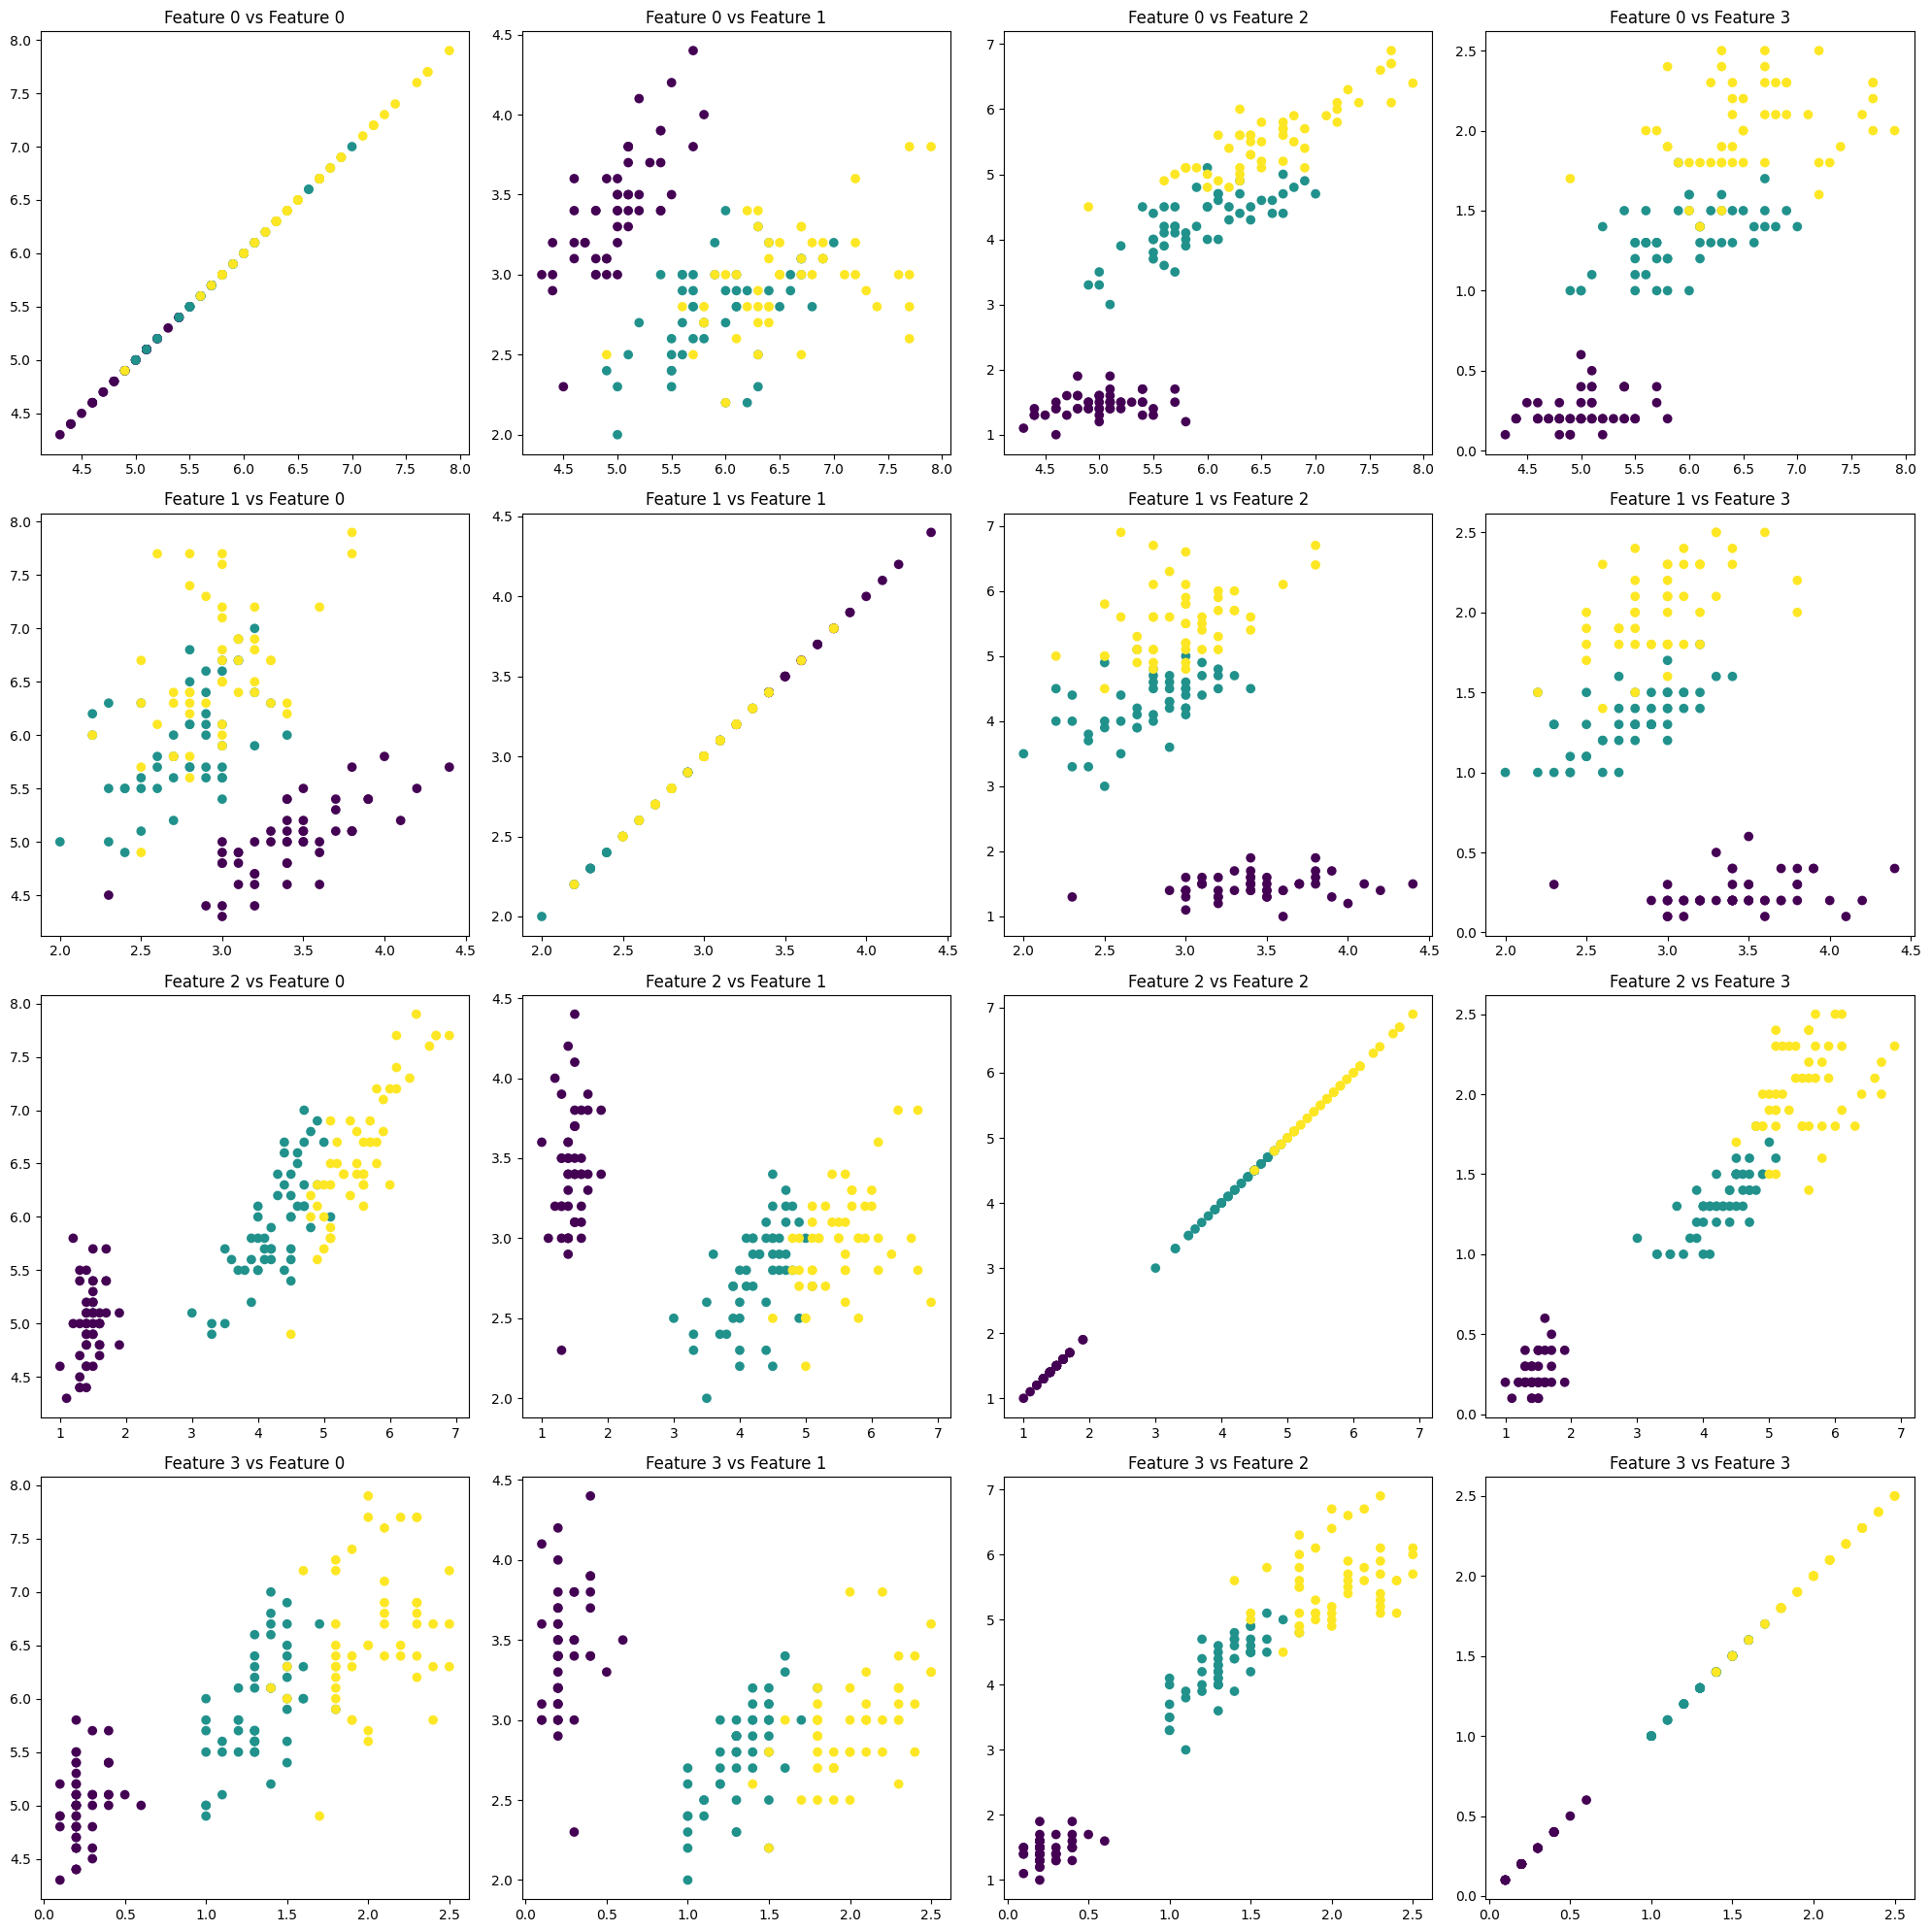

In [28]:
## Visualise the plots using all pairs of features

# Create subplots
fig, axs = plt.subplots(4, 4, figsize=(20, 20))

# Plot Linear SVM
for i in range(4):
    for j in range(4):
        axs[i, j].scatter(X[:, i], X[:, j], c=y)
        axs[i, j].set_title('Feature ' + str(i) + ' vs Feature ' + str(j))

# Adjust spacing between subplots
plt.tight_layout()

# Show the plots
plt.show()


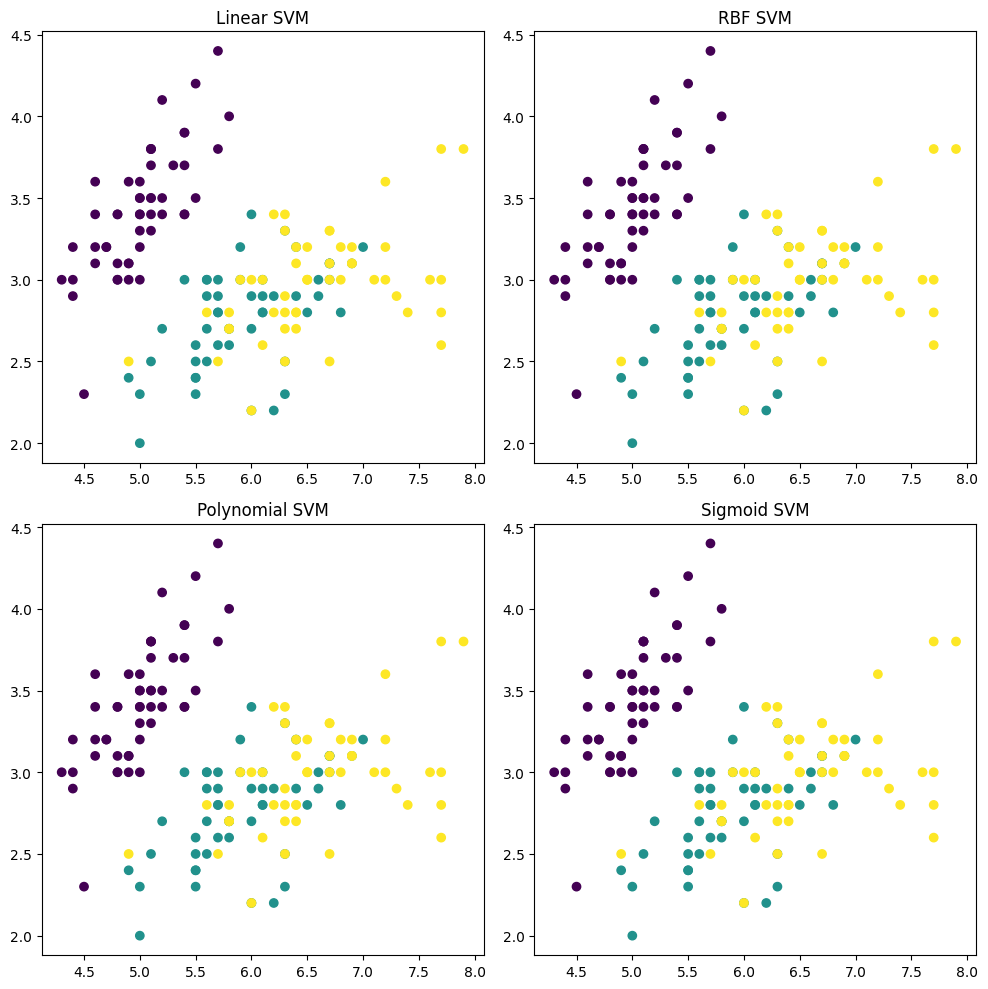

In [32]:
#Plot the decision boundary

# Create subplots

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Plot Linear SVM
axs[0, 0].scatter(X[:, 0], X[:, 1], c=y)
axs[0, 0].set_title('Linear SVM')

# Plot RBF SVM
axs[0, 1].scatter(X[:, 0], X[:, 1], c=y)
axs[0, 1].set_title('RBF SVM')

# Plot Polynomial SVM
axs[1, 0].scatter(X[:, 0], X[:, 1], c=y)
axs[1, 0].set_title('Polynomial SVM')

# Plot Sigmoid SVM
axs[1,1].scatter(X[:, 0], X[:, 1], c=y)
axs[1,1].set_title('Sigmoid SVM')

plt.tight_layout()

# Show the plots
plt.show()